In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import cohen_kappa_score
from itertools import combinations
import numpy as np

This notebook covers the first three steps of my analysis plan:

1. Compare theoretical AI exposure to observed AI usage
2. Identify different AI transition archetypes
3. Understand whether AI use leans toward automation or augmentation

The data is at the SOC occupation level (1,016 SOC occupations). Not every occupation has values, mainly for the Anthropic data, because of privacy thresholds and thin usage in some fields (military occupations, for example, have almost no data). These are kept as null values.

> **Status:** code fixes were made in September 2026 (see the note in Step 2c). Outputs from Step 2c onward reflect the previous run until the notebook is rerun.

# Step 1  - Compare AI Exposure to AI Usage

## a) Showing the Benefit of C-AIOE over AIOE as a way to measure Theoretical AI Exposure

### Definition of the Data and Metrics
Before comparing the metrics, I first define what each measure represents and what I expect to observe in the correlation matrix.

1. `AIOE` is the AI Occupational Exposure index from the World Bank. Its values range from approximately 5 to 7 in my dataset. Since AIOE is an index, the absolute value is less important than the relative exposure of occupations to one another.

2. `Complementarity` measures the extent to which AI is expected to complement or augment human work rather than automate it. The metric ranges from 0% to 100%, with higher values indicating greater potential for augmentation.

3. `C-AIOE` is my complementarity-adjusted AIOE measure. I interpret this as a theoretical measure of a job's potential risk of being automated or replaced by AI. Since C-AIOE incorporates both AI exposure and complementarity, I expect it to increase as AIOE increases and decrease as complementarity increases.

4. `Observed Exposure` is based on Anthropic's observed Claude usage data and is defined as the share of a job being performed or accelerated by an LLM. Because Anthropic's methodology incorporates [automation into the calculation of Observed Exposure](https://cdn.sanity.io/files/4zrzovbb/website/e5f77fc0e77c0185110b5e4b909602791ae76eae.pdf), higher automation should correspond to higher observed exposure. I therefore interpret this as an observed measure of a job's potential AI automation risk.

### Motivation of Choosing C-AIOE over AIOE as the Main Metric to Compare Against Observed Exposure
The motivation for using C-AIOE rather than AIOE when comparing against Observed Exposure is that the two measures should be compared on a similar conceptual basis. AIOE captures AI exposure alone, whereas Observed Exposure incorporates both exposure to AI and the extent to which AI can automate the work. C-AIOE similarly combines AI exposure with complementarity to produce a single measure that accounts for both dimensions. In other words, Observed Exposure combines exposure and complementarity-related information into one observed measure, while C-AIOE combines exposure and complementarity into one theoretical measure. Comparing C-AIOE with Observed Exposure therefore provides a more conceptually comparable comparison than using AIOE alone.

### Granularity

Of the 1,016 SOC codes, 537 (53%) have complete data for every measure used here: AIOE, Complementarity, C-AIOE, Observed Exposure, and the Anthropic automation and augmentation shares. Steps 1 to 3 all use these 537 occupations.

In [2]:
ai_metrics_df = pd.read_csv('../data/auxiliary/soc_consolidated_ai_metrics.csv')

columns_to_keep = [
    "O*NET-SOC Code",
    "Title",
    "AIOE",
    "Complementarity",
    "C-AIOE",
    "Observed Exposure",
    "Augmentation Percent",
    "Automation Percent",
    "Directive Percent",
    "Feedback Loop Percent",
    "Learning Percent",
    "Task Iteration Percent",
    "Validation Percent",
    "None Percent",
    "Date Data Released",
]
# exposure_df = ai_metrics_df[columns_to_keep]
exposure_df = ai_metrics_df[columns_to_keep].dropna()

# get the data from Eloundou et al. (2023)
open_ai_df = pd.read_csv('../data/ai_measurements/occ_level.csv')
exposure_df = exposure_df.merge(open_ai_df, on='O*NET-SOC Code', how='left')

## b) Showing that there exists a big difference between AIOE and C-AIOE

### Definition of the Data and Metrics
TL;DR: For all columns, a higher value generally indicates greater AI exposure or risk, except for `Complementarity`, where a higher value indicates greater potential for AI to complement rather than substitute human work.

1. `nth Top AIOE (AIOE Rank)`

An occupation's percentile rank on AIOE, from 0 to 1. A value closer to 1 means greater AI exposure relative to other occupations.

2. `nth Top C-AIOE (C-AIOE Rank)`

The same percentile rank, but using the complementarity-adjusted AIOE (C-AIOE).

3. `Increase in Exposure (Rank Change)`

C-AIOE rank minus AIOE rank. A positive value means the occupation looks more exposed once complementarity is taken into account. A negative value means it looks less exposed.

4. `Increase in Exposure (Rank Change) Percent`

The rank change as a percentage of the original AIOE rank.

### Main Insight
1. Across the 537 occupations, the average rank change is 0 and the median is close to 0 (-0.01). The spread is large, though: the standard deviation is 0.25 and changes run from -0.77 to +0.82. Adjusting for complementarity reorders many individual jobs even though it does not shift the overall distribution.
2. The largest drops in exposure are for Management (-0.26), Healthcare Practitioners (-0.22), Community and Social Service (-0.21), Education (-0.20) and Legal (-0.17). The largest increases are for Food Preparation (+0.31), Production (+0.26) and Office and Administrative Support (+0.22).
3. Group averages hide large differences within groups. In Legal, judges fall 0.72 (-72%) and lawyers fall 0.46 (-48%), while paralegals rise 0.12 (+17%). The drop for Legal is driven by roles with high responsibility and decision-making, not by the most common legal jobs.

In [3]:
exposure_df["nth Top AIOE (AIOE Rank)"] = (
    exposure_df["AIOE"]
    #.rank(ascending=False, method="min")
    .rank(pct=True)
)
#).astype(int)

exposure_df["nth Top C-AIOE (C-AIOE Rank)"] = (
    exposure_df["C-AIOE"]
    #.rank(ascending=False, method="min")
    .rank(pct=True)
)
#).astype(int)

exposure_df["Increase in Exposure (Rank Change)"] = (
    exposure_df["nth Top C-AIOE (C-AIOE Rank)"] - 
    exposure_df["nth Top AIOE (AIOE Rank)"]
)

exposure_df["Increase in Exposure (Rank Change) Percent"] = (exposure_df["Increase in Exposure (Rank Change)"] / exposure_df["nth Top AIOE (AIOE Rank)"]) * 100
exposure_df = exposure_df.sort_values(by='Increase in Exposure (Rank Change) Percent', ascending=False)

In [4]:
exposure_df['Increase in Exposure (Rank Change)'].describe()

count    5.370000e+02
mean     1.323171e-17
std      2.516456e-01
min     -7.653631e-01
25%     -1.787709e-01
50%     -7.448790e-03
75%      1.713222e-01
max      8.230912e-01
Name: Increase in Exposure (Rank Change), dtype: float64

<Axes: >

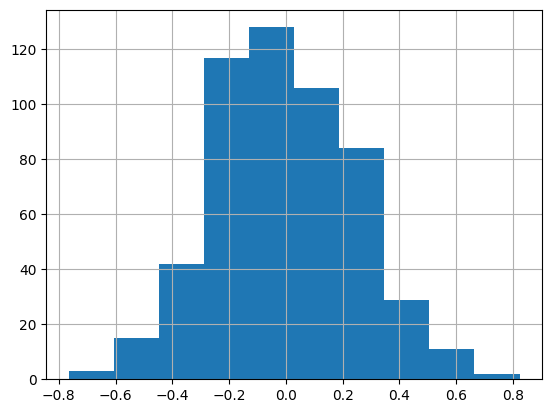

In [5]:
exposure_df['Increase in Exposure (Rank Change)'].hist()

In [6]:
exposure_df[
    [
        'O*NET-SOC Code', 
        'Title_x', 
        'nth Top AIOE (AIOE Rank)', 
        'nth Top C-AIOE (C-AIOE Rank)', 
        'Increase in Exposure (Rank Change)', 
        #'Increase in Exposure (Rank Change) Percent'
    ]
].sort_values(by='Increase in Exposure (Rank Change)')

,O*NET-SOC Code,Title_x,nth Top AIOE (AIOE Rank),nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change)
279,29-1217.00,Neurologists,0.901304,0.135940,-0.765363
163,23-1023.00,"Judges, Magistrate Judges, and Magistrates",0.998138,0.277467,-0.720670
0,11-1011.00,Chief Executives,0.921788,0.202980,-0.718808
20,11-9032.00,"Education Administrators, Kindergarten through...",0.823091,0.229050,-0.594041
157,21-2011.00,Clergy,0.949721,0.385475,-0.564246
...,...,...,...,...,...
224,27-1013.00,"Fine Artists, Including Painters, Sculptors, a...",0.208566,0.828678,0.620112
430,43-9071.00,"Office Machine Operators, Except Computer",0.227188,0.871508,0.644320
223,27-1012.00,Craft Artists,0.121043,0.769088,0.648045
497,51-6062.00,"Textile Cutting Machine Setters, Operators, an...",0.076350,0.813780,0.737430


In [7]:
exposure_df[(exposure_df['Increase in Exposure (Rank Change) Percent'] > -50 ) & (exposure_df['Increase in Exposure (Rank Change) Percent'] < 50)][[        'nth Top AIOE (AIOE Rank)', 
        'O*NET-SOC Code', 
        'Title_x', 
        'nth Top C-AIOE (C-AIOE Rank)', 
        'Increase in Exposure (Rank Change)', 
        'Increase in Exposure (Rank Change) Percent']]

,nth Top AIOE (AIOE Rank),O*NET-SOC Code,Title_x,nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change),Increase in Exposure (Rank Change) Percent
400,0.659218,43-4051.00,Customer Service Representatives,0.986965,0.327747,49.717514
228,0.270019,27-1023.00,Floral Designers,0.404097,0.134078,49.655172
387,0.614525,43-2011.00,"Switchboard Operators, Including Answering Ser...",0.912477,0.297952,48.484848
214,0.530726,25-4011.00,Archivists,0.787709,0.256983,48.421053
465,0.054004,49-3042.00,"Mobile Heavy Equipment Mechanics, Except Engines",0.080074,0.026071,48.275862
...,...,...,...,...,...,...
21,0.981378,11-9033.00,"Education Administrators, Postsecondary",0.515829,-0.465549,-47.438330
206,0.752328,25-2031.00,"Secondary School Teachers, Except Special and ...",0.394786,-0.357542,-47.524752
159,0.951583,23-1011.00,Lawyers,0.495345,-0.456238,-47.945205
469,0.147114,49-9021.00,"Heating, Air Conditioning, and Refrigeration M...",0.076350,-0.070764,-48.101266


In [8]:
# Add major group
major_groups = {
    "11": "Management",
    "13": "Business and Financial Operations",
    "15": "Computer and Mathematical",
    "17": "Architecture and Engineering",
    "19": "Life, Physical, and Social Science",
    "21": "Community and Social Service",
    "23": "Legal",
    "25": "Educational Instruction and Library",
    "27": "Arts, Design, Entertainment, Sports, and Media",
    "29": "Healthcare Practitioners and Technical",
    "31": "Healthcare Support",
    "33": "Protective Service",
    "35": "Food Preparation and Serving Related",
    "37": "Building and Grounds Cleaning and Maintenance",
    "39": "Personal Care and Service",
    "41": "Sales and Related",
    "43": "Office and Administrative Support",
    "45": "Farming, Fishing, and Forestry",
    "47": "Construction and Extraction",
    "49": "Installation, Maintenance, and Repair",
    "51": "Production",
    "53": "Transportation and Material Moving",
    "55": "Military"
}
exposure_df['Major Group'] = exposure_df['O*NET-SOC Code'].str[:2].map(major_groups)

### Notes for further analysis

- **Benchmark percentages.** When reporting a percentage change, show the old and new rank side by side so the reader has context.
- **Visualize the shift.** Show how the Legal group moves from its AIOE rank to its C-AIOE rank.
- **Look inside the group.** Done for Legal (see the table below): judges and lawyers drop sharply, while paralegals rise. The same check should be repeated for Management and the other groups with large drops.
- **Weight by employment.** Paralegals, law clerks and lawyers are the most common roles in Legal. A group average weighted by employment would better reflect the typical worker.

One way to show this: plot each occupation's original AIOE rank, with an arrow pointing up or down to its C-AIOE rank.

In [9]:
grouped_occupations_exposure = exposure_df.groupby('Major Group')[['nth Top AIOE (AIOE Rank)', 'nth Top C-AIOE (C-AIOE Rank)', 'Increase in Exposure (Rank Change)']].mean()
grouped_occupations_exposure.sort_values(by='Increase in Exposure (Rank Change)')

,nth Top AIOE (AIOE Rank),nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change)
Major Group,,,
Management,0.683031,0.426669,-0.256363
Healthcare Practitioners and Technical,0.455456,0.235903,-0.219553
Community and Social Service,0.713066,0.503880,-0.209187
Educational Instruction and Library,0.728319,0.524441,-0.203877
Legal,0.916733,0.744347,-0.172386
Protective Service,0.295469,0.188392,-0.107076
"Life, Physical, and Social Science",0.660786,0.573361,-0.087425
Business and Financial Operations,0.848231,0.818221,-0.030010
Architecture and Engineering,0.627621,0.602631,-0.024989


In [10]:
exposure_df[exposure_df['Major Group'] == 'Legal'][['O*NET-SOC Code', 'Title_x', 'nth Top AIOE (AIOE Rank)', 'nth Top C-AIOE (C-AIOE Rank)', 'Increase in Exposure (Rank Change)', 'Increase in Exposure (Rank Change) Percent']]

,O*NET-SOC Code,Title_x,nth Top AIOE (AIOE Rank),nth Top C-AIOE (C-AIOE Rank),Increase in Exposure (Rank Change),Increase in Exposure (Rank Change) Percent
164,23-2011.00,Paralegals and Legal Assistants,0.756052,0.880819,0.124767,16.502463
165,23-2093.00,"Title Examiners, Abstractors, and Searchers",0.845438,0.884544,0.039106,4.625551
160,23-1012.00,Judicial Law Clerks,0.940410,0.949721,0.009311,0.990099
162,23-1022.00,"Arbitrators, Mediators, and Conciliators",0.931099,0.862197,-0.068901,-7.400000
161,23-1021.00,"Administrative Law Judges, Adjudicators, and H...",0.994413,0.860335,-0.134078,-13.483146
159,23-1011.00,Lawyers,0.951583,0.495345,-0.456238,-47.945205
163,23-1023.00,"Judges, Magistrate Judges, and Magistrates",0.998138,0.277467,-0.720670,-72.201493


# c) Univariate & Bivariate Analysis of C-AIOE and Observed Exposure

C-AIOE is roughly bell-shaped, while Observed Exposure is strongly right-skewed. Across the 537 occupations, at least a quarter have an Observed Exposure of 0, the median is 0.03 and the mean is 0.10. This skew is why I treat zero usage separately when setting the high/low threshold in Step 2c.

In [11]:
exposure_df[['C-AIOE', 'Observed Exposure']].describe()

,C-AIOE,Observed Exposure
count,537.000000,537.000000
mean,4.732421,0.103669
std,0.604165,0.146884
min,3.204920,0.000000
25%,4.318391,0.000000
50%,4.715776,0.034200
75%,5.160867,0.165100
max,6.270814,0.745100


The right skew is expected, since Observed Exposure only reflects people who already use Claude.

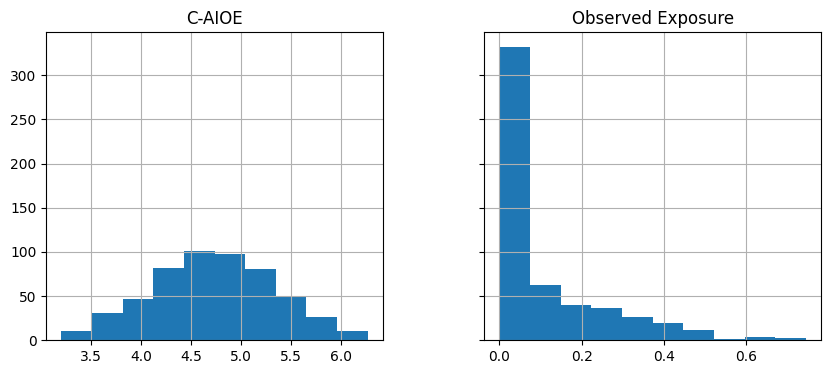

In [12]:
fig, axs = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
exposure_df[['C-AIOE', 'Observed Exposure']].hist(ax=axs)
plt.show()

For the bivariate relationship, the Pearson correlation between C-AIOE and Observed Exposure is 0.52, a moderate positive association. This is notable because C-AIOE was built independently of Observed Exposure. For comparison, the Human Beta and LLM Beta measures, which are inputs to Observed Exposure, correlate at 0.54 and 0.61 with it. C-AIOE is only slightly weaker than Human Beta, even though it shares no inputs with the observed measure.

In [13]:
exposure_df[['C-AIOE', 'dv_rating_beta', 'human_rating_beta', 'Observed Exposure']].corr()['Observed Exposure'].round(2)

C-AIOE               0.52
dv_rating_beta       0.61
human_rating_beta    0.54
Observed Exposure    1.00
Name: Observed Exposure, dtype: float64

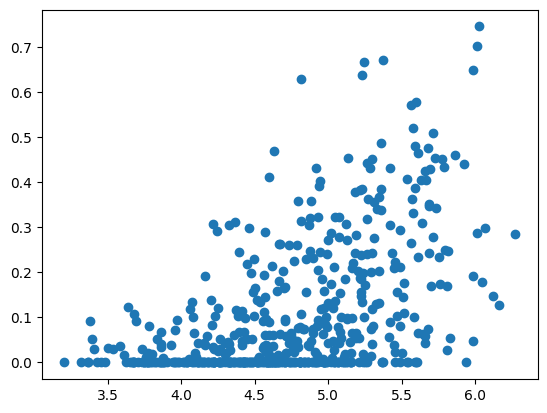

In [14]:
plt.scatter(exposure_df['C-AIOE'], exposure_df['Observed Exposure'])

# Step 2 - Identify different AI transition archetypes

## a) Identify the different AI transition archetypes based on the chosen Theoretical AI Exposure and Observed AI Exposure

The goal is to find which approach gives the most useful basis for identifying AI transition archetypes. I use a percentile approach: I convert C-AIOE to its empirical percentile so that it is bounded between 0 and 1, like Observed Exposure. This makes the two measures directly comparable.

In [15]:
# get the percentile for the C-AIOE
exposure_df["C-AIOE Percentile"] = exposure_df["C-AIOE"].rank(pct=True)

In [16]:
def classify_transition_archetype(
    job: pd.Series,
    theoretical_column: str,
    observed_percentile_threshold: int = 50,
    exposure_df: pd.DataFrame = exposure_df,
) -> str:
    """Classify a job into an AI transition archetype.

    Classification is based on whether the job's theoretical AI
    exposure and observed AI exposure are below or above their
    respective medians across all occupations.

    Args:
        job: A pandas Series representing a single occupation.
        theoretical_column: Name of the theoretical AI exposure
            column used for classification.
        exposure_df: DataFrame containing AI exposure measures
            across occupations.

    Returns:
        The AI transition archetype assigned to the job.
    """
    # get the medians
    theoretical_median = exposure_df[theoretical_column].median()
    non_zero_df = exposure_df[exposure_df["Observed Exposure"] > 0]
    # observed_exposure_median = exposure_df["Observed Exposure"].median() # move this around so that w
    observed_percentile_threshold = observed_percentile_threshold / 100
    positive_observed_median = non_zero_df["Observed Exposure"].quantile(
        observed_percentile_threshold
    )

    # get the job's actual theoretical and observed job exposure
    theoretical_job = job[theoretical_column]
    observed_exposure_job = job["Observed Exposure"]

    # create the boolean
    theoretical_exposure_low = theoretical_job <= theoretical_median
    observed_exposure_low = observed_exposure_job <= positive_observed_median

    #if not present at all, just put as Unknown
    if pd.isna(theoretical_job) or pd.isna(observed_exposure_job):
        return "Unknown"

    if theoretical_exposure_low:
        if observed_exposure_low:
            return "Limited Current Transformation" # low theoretical and observed
        return "AI-Enabled Expansion" # low theoretical but high observed

    if observed_exposure_low:
        return "Latent Transformation" # high theoretical but low observed

    return "Active Transformation" # high theoretical and observed

## b) Determining if there exists reasonably stable AI transition archetypes

To determine whether reasonably stable AI transition archetypes exist, I use Cohen's Kappa ($\kappa$) to measure the agreement between the classifications produced by different theoretical exposure measures. Cohen's Kappa measures agreement between two categorical classifications while accounting for the agreement that would be expected by chance. The statistic ranges from $-1$ to $1$, where $1$ represents perfect agreement and $0$ represents agreement equivalent to chance. Under the commonly used interpretation of Landis and Koch (1977), values between $0.41$ and $0.60$ represent moderate agreement.

I therefore define an AI transition archetype classification as reasonably stable when the Cohen's Kappa between the archetypes derived from C-AIOE and those derived from the selected benchmark theoretical exposure measure is greater than $0.41$, corresponding to at least moderate agreement under this interpretation.

For the benchmark comparison, I use the Human and LLM Beta measure developed in Labor market impacts of AI: A new measure and early evidence by Massenkoff and McCrory [(2026)](https://www.anthropic.com/research/labor-market-impacts). This measure is selected because it was used as a theoretical exposure measure in the study's comparison of theoretical AI exposure with observed AI exposure. The Human and LLM Beta measure therefore provides a relevant benchmark for evaluating whether the transition archetypes identified using C-AIOE are consistent with the theoretical exposure framework used by Anthropic, which builds on [Eloundou et al. (2023)](https://arxiv.org/abs/2303.10130).

In [17]:
theoretical_exposure_measurments = [
    #"AIOE",
    #"C-AIOE",
    "C-AIOE Percentile",
    #"Observed Exposure",
    #"dv_rating_alpha",
    "dv_rating_beta",
    #"dv_rating_gamma",
    #"human_rating_alpha",
    "human_rating_beta",
    #"human_rating_gamma",
]


# apply and classify each job into a transition archetype
archetype_columns = [
    f"Archetype {measurement}"
    for measurement in theoretical_exposure_measurments
]
for theoretical_exposure_measurment in theoretical_exposure_measurments:
    col_name = "Archetype " + theoretical_exposure_measurment
    exposure_df[col_name] = exposure_df.apply(
        classify_transition_archetype,
        theoretical_column=theoretical_exposure_measurment,
        axis=1
    )

In [18]:
kappas = {'Archetype 1':[], 'Archetype 2': [], "Cohen's Kappa": []}
for measurement1, measurement2 in combinations(archetype_columns, 2):
    kappa = cohen_kappa_score(
        exposure_df[measurement1], exposure_df[measurement2]
    )
    kappas['Archetype 1'].append(measurement1)
    kappas['Archetype 2'].append(measurement2)
    kappas["Cohen's Kappa"].append(kappa)

kappas_df = pd.DataFrame(kappas)
kappas_df.sort_values(by="Cohen's Kappa")

,Archetype 1,Archetype 2,Cohen's Kappa
1,Archetype C-AIOE Percentile,Archetype human_rating_beta,0.609329
0,Archetype C-AIOE Percentile,Archetype dv_rating_beta,0.631651
2,Archetype dv_rating_beta,Archetype human_rating_beta,0.796017


In [ ]:
# Question 1: how much does the choice of theoretical measure change the archetypes?
comparison_counts = pd.DataFrame(
    {column: exposure_df[column].value_counts() for column in archetype_columns}
).fillna(0).astype(int)
display(comparison_counts)

switch_share = (
    exposure_df["Archetype C-AIOE Percentile"] != exposure_df["Archetype human_rating_beta"]
).mean()
print(f"Share of jobs that change archetype between C-AIOE and Human Beta: {switch_share:.0%}")

pd.crosstab(
    exposure_df["Archetype C-AIOE Percentile"],
    exposure_df["Archetype human_rating_beta"],
)

## c) Determining what is the best percentile threshold

Here I adjust the percentile threshold for Observed Exposure to recalibrate the AI transition archetypes.

The idea is to split occupations into two groups based on Observed Exposure:

* **Zero observed usage:** occupations with Observed Exposure = 0 are classified as Low Usage. With no observed AI exposure, they clearly belong there.
* **Positive observed usage:** occupations with Observed Exposure > 0 are compared against a percentile threshold within the positive Observed Exposure distribution.

  * At or below the threshold -> Low Usage
  * Above the threshold -> High Usage

Because Observed Exposure is highly right-skewed, I test several percentile thresholds and look at how the number of occupations in each archetype changes.

In the previous run, the 50th percentile gave a larger Latent Transformation group than Active Transformation group. That matches the expectation that Latent Transformation should be the larger group. However, that run used Human Beta by mistake (see the note below), so the counts need to be confirmed after rerunning. The sensitivity check below compares the 50th percentile with other cut-offs.

So 50% is my working choice for the Observed Exposure threshold, pending the rerun and the sensitivity check. Once the threshold is set, I move on to the Step 3 automation and augmentation analysis.

> **Note on the outputs below (September 2026).** In the previous run, the threshold cell below reused a leftover loop variable, so the column labelled `Archetype C-AIOE` was actually built from `human_rating_beta`. The code is now fixed to use `C-AIOE Percentile` explicitly, and the sub-archetype is now applied to Active Transformation only. The printed outputs from this point on still come from the previous run and will update when the notebook is rerun.

In [19]:
# now do it where we change around the percentile threshold for the observed exposure greater than 0
thresholds = range(50, 60)
for observed_percentile_threshold in thresholds:
    col_name = "Archetype C-AIOE " + str(observed_percentile_threshold)
    exposure_df[col_name] = exposure_df.apply(
        classify_transition_archetype,
        theoretical_column="C-AIOE Percentile",
        observed_percentile_threshold=observed_percentile_threshold,
        axis=1
    )

archetype_numbered_columns = [
    f"Archetype C-AIOE {observed_percentile_threshold}"
    for observed_percentile_threshold in thresholds
]

# kappas = {'Archetype 1':[], 'Archetype 2': [], "Cohen's Kappa": []}
# for measurement1, measurement2 in combinations(archetype_numbered_columns, 2):
#     kappa = cohen_kappa_score(
#         exposure_df[measurement1], exposure_df[measurement2]
#     )
#     kappas['Archetype 1'].append(measurement1)
#     kappas['Archetype 2'].append(measurement2)
#     kappas["Cohen's Kappa"].append(kappa)

# kappas_df = pd.DataFrame(kappas)
# kappas_df

In [ ]:
# Question 2: how sensitive are the archetypes to the observed-usage threshold?
theoretical_high = exposure_df["C-AIOE Percentile"] > exposure_df["C-AIOE Percentile"].median()
positive_observed = exposure_df.loc[exposure_df["Observed Exposure"] > 0, "Observed Exposure"]

observed_cutoffs = {
    "Positive-only P25": positive_observed.quantile(0.25),
    "Positive-only P50 (current)": positive_observed.quantile(0.50),
    "Positive-only P75": positive_observed.quantile(0.75),
    "Overall median": exposure_df["Observed Exposure"].median(),
    "Overall mean (z > 0)": exposure_df["Observed Exposure"].mean(),
}

def label_archetype(theory_is_high, usage_is_high):
    if theory_is_high and usage_is_high:
        return "Active Transformation"
    if theory_is_high:
        return "Latent Transformation"
    if usage_is_high:
        return "AI-Enabled Expansion"
    return "Limited Current Transformation"

sensitivity_df = pd.DataFrame(index=exposure_df.index)
for rule_name, cutoff in observed_cutoffs.items():
    usage_high = exposure_df["Observed Exposure"] > cutoff
    sensitivity_df[rule_name] = [
        label_archetype(t, u) for t, u in zip(theoretical_high, usage_high)
    ]

baseline = "Positive-only P50 (current)"
sensitivity_summary = pd.DataFrame(
    {rule: sensitivity_df[rule].value_counts() for rule in sensitivity_df}
).T.fillna(0).astype(int)
sensitivity_summary["Cut-off value"] = pd.Series(observed_cutoffs).round(4)
sensitivity_summary["Share of jobs rated high usage"] = [
    (exposure_df["Observed Exposure"] > observed_cutoffs[rule]).mean().round(2)
    for rule in sensitivity_summary.index
]
sensitivity_summary["Share that switch vs. current"] = [
    (sensitivity_df[rule] != sensitivity_df[baseline]).mean().round(2)
    for rule in sensitivity_summary.index
]
sensitivity_summary["Cohen's Kappa vs. current"] = [
    round(cohen_kappa_score(sensitivity_df[rule], sensitivity_df[baseline]), 2)
    for rule in sensitivity_summary.index
]
sensitivity_summary

### Notes on the AI-Enabled Expansion group

- Medical transcriptionists look like an outlier in this group and are worth a closer look.
- This small group exists only because of where the cut-off falls, so it is very sensitive to method choices.
- These jobs may score high on complementarity.
- A more accurate name might be "Higher Observed than Expected", since there is no clear driver behind them.

In [20]:
exposure_df[exposure_df['Title_x'] == 'Judges, Magistrate Judges, and Magistrates'][['C-AIOE Percentile', 'dv_rating_beta']]

,C-AIOE Percentile,dv_rating_beta
163,0.277467,0.416667


In [21]:
exposure_df[exposure_df['Archetype C-AIOE 50'] == 'AI-Enabled Expansion'][[
    'Title_x', 
    'Complementarity',
    'dv_rating_beta', 
    'C-AIOE Percentile',
    'human_rating_beta',
    'Observed Exposure'
]]

,Title_x,Complementarity,dv_rating_beta,C-AIOE Percentile,human_rating_beta,Observed Exposure
224,"Fine Artists, Including Painters, Sculptors, a...",45.937500,0.425000,0.828678,0.312500,0.3565
373,Retail Salespersons,56.645833,0.342105,0.618250,0.355263,0.3222
141,"Geological Technicians, Except Hydrologic Tech...",58.166667,0.390244,0.573557,0.304878,0.2290
253,"Camera Operators, Television, Video, and Film",60.625000,0.424242,0.353818,0.181818,0.1651
391,"Bookkeeping, Accounting, and Auditing Clerks",51.208333,0.802326,0.927374,0.313953,0.3104
313,Medical Transcriptionists,56.791667,0.875000,0.783985,0.232143,0.6365
252,Photographers,61.083333,0.385417,0.383613,0.218750,0.1950
87,Computer Hardware Engineers,53.583333,0.727273,0.886406,0.318182,0.1453
137,Food Science Technicians,62.687500,0.357143,0.482309,0.285714,0.2038
162,"Arbitrators, Mediators, and Conciliators",56.291667,0.500000,0.862197,0.370968,0.2426


In [22]:
# Time to actually export this
final_exposure_df = exposure_df.rename(
    columns={
        "Title_x": "Title",
        "dv_rating_beta": "LLM Rating Beta",
        "human_rating_beta": "Human Rating Beta",
        "Archetype C-AIOE 50": "Archetype C-AIOE",
    }
)

columns_to_keep = [
    "O*NET-SOC Code",
    "Title",
    "Major Group",
    "AIOE",
    "Complementarity",
    "C-AIOE",
    "Observed Exposure",
    "LLM Rating Beta",
    "Human Rating Beta",
    "Archetype C-AIOE",
    "Augmentation Percent",
    "Automation Percent",
    "Directive Percent",
    "Feedback Loop Percent",
    "Learning Percent",
    "Task Iteration Percent",
    "Validation Percent",
    "None Percent",
    "Date Data Released",
]

final_exposure_df = final_exposure_df[columns_to_keep]

## d) What are the archetypes composed of?

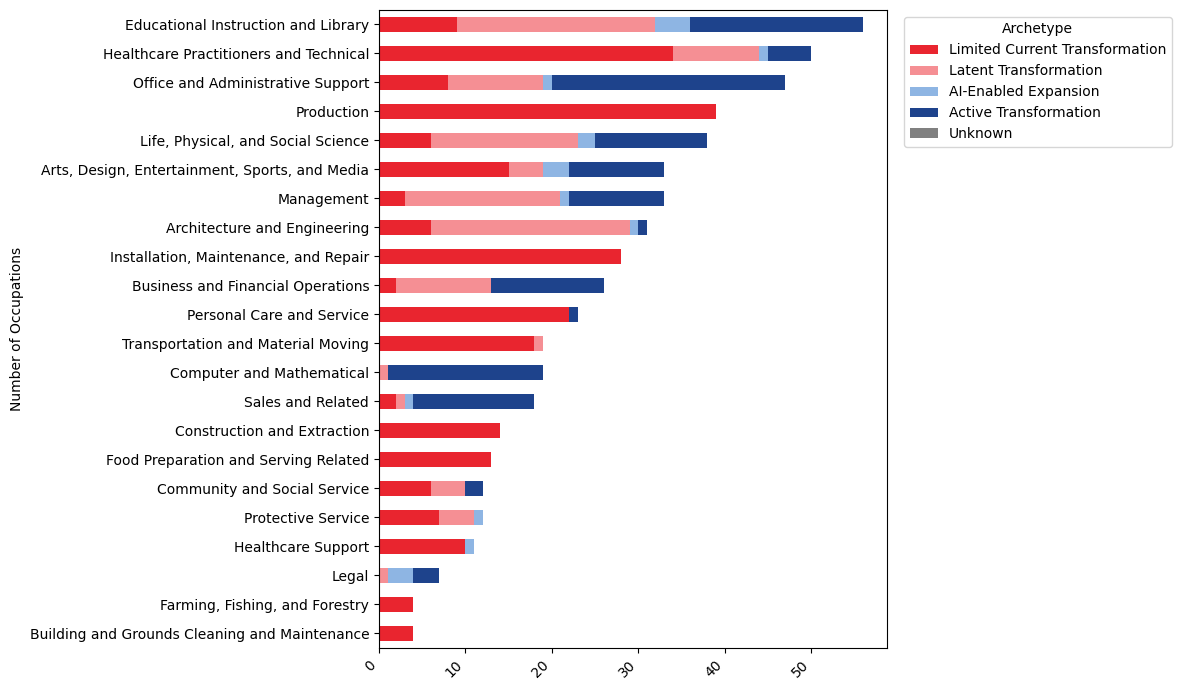

In [23]:
archetype_counts = pd.crosstab(
    final_exposure_df["Major Group"],
    final_exposure_df["Archetype C-AIOE"],
)

archetype_order = [
    "Limited Current Transformation",
    "Latent Transformation",
    "AI-Enabled Expansion",
    "Active Transformation",
    "Unknown"
]

archetype_counts = archetype_counts.reindex(
    columns=archetype_order,
    fill_value=0,
)

archetype_counts = archetype_counts.loc[
    archetype_counts.sum(axis=1).sort_values(ascending=False).index
]

archetype_colors = [
    "#e9252f",
    "#f58f94",
    "#8eb5e3",
    "#1e438c",
    "gray"
]

ax = archetype_counts[::-1].plot(
    kind="barh",
    stacked=True,
    figsize=(12, 7),
    color=archetype_colors,
)

#ax.set_xlabel("")
ax.set_ylabel("Number of Occupations")
#ax.set_title("AI Transition Archetypes by Major Group")

ax.legend(
    title="Archetype",
    bbox_to_anchor=(1.02, 1),
    loc="upper left",
)

plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Step 3 - Understand whether AI use is automation or augmentation

## a) Exploratory Data Analysis of the relationship between Archetypes to Automation/Augmentation Share

In [24]:
complementarity_measures = [
    "Augmentation Percent",
    "Automation Percent",
    "Directive Percent",
    "Feedback Loop Percent",
    "Learning Percent",
    "Task Iteration Percent",
    "Validation Percent",
    "None Percent",
]

final_exposure_df.groupby('Archetype C-AIOE')[complementarity_measures].agg(['mean', 'median'])

Augmentation Percent        Automation Percent  \
                                               mean median               mean   
Archetype C-AIOE                                                                
AI-Enabled Expansion                      50.472105  55.27          49.527895   
Active Transformation                     50.930647  52.36          49.069353   
Latent Transformation                     55.624806  57.63          44.375194   
Limited Current Transformation            42.131760  44.59          57.868520   

                                      Directive Percent          \
                               median              mean  median   
Archetype C-AIOE                                                  
AI-Enabled Expansion            44.73         38.381053  38.240   
Active Transformation           47.64         33.338921  30.250   
Latent Transformation           42.37         31.577984  29.380   
Limited Current Transformation  55.41         37.873720  35.275   

                               Feedback Loop Percent        Learning Percent  \
                                                mean median             mean   
Archetype C-AIOE                                                               
AI-Enabled Expansion                       10.560000   6.89        16.337895   
Active Transformation                      14.490719   9.62        15.054964   
Latent Transformation                      12.012481  10.58        22.112016   
Limited Current Transformation             16.901680  12.86        14.443400   

                                      Task Iteration Percent         \
                               median                   mean median   
Archetype C-AIOE                                                      
AI-Enabled Expansion            14.00              30.972105  33.33   
Active Transformation           10.26              31.476115  29.17   
Latent Transformation           17.24              28.017519  26.37   
Limited Current Transformation   8.99              22.523080  19.64   

                               Validation Percent        None Percent         
                                             mean median         mean median  
Archetype C-AIOE                                                              
AI-Enabled Expansion                     2.570000  2.390     1.178947  0.970  
Active Transformation                    3.290072  2.440     2.349712  1.100  
Latent Transformation                    4.614961  3.200     1.664186  1.110  
Limited Current Transformation           3.162640  2.025     5.095440  1.445

The first test checks whether the archetypes differ on each AI measure. They do.

In [25]:
from scipy.stats import kruskal, ttest_ind

# test for differences in each AI measure across archetypes
for measure in complementarity_measures:
    groups = [
        group[measure].dropna()
        for _, group in final_exposure_df.groupby("Archetype C-AIOE")
    ]

    statistic, p_value = kruskal(*groups)

    print(f"{measure}: H={statistic:.3f}, p={p_value:.4f}")

Augmentation Percent: H=51.905, p=0.0000
Automation Percent: H=51.905, p=0.0000
Directive Percent: H=14.163, p=0.0027
Feedback Loop Percent: H=22.683, p=0.0000
Learning Percent: H=24.668, p=0.0000
Task Iteration Percent: H=39.580, p=0.0000
Validation Percent: H=15.623, p=0.0014
None Percent: H=4.811, p=0.1862


Note that I do not compare any archetype against AI-Enabled Expansion, because very few jobs fall into it.

The more interesting question for me is whether Latent Transformation and Limited Current Transformation differ. Both have low Observed Exposure, but Latent Transformation has high theoretical exposure while Limited Current Transformation has low theoretical exposure. In the previous run, Latent Transformation had a much higher median augmentation share (57.6%) than Limited Current Transformation (44.6%), and a t-test found the difference statistically significant. Because that run used Human Beta by mistake, I will confirm this result after rerunning with C-AIOE.

In [26]:
# two-sample t-test
group_a = final_exposure_df[
    final_exposure_df["Archetype C-AIOE"] == "Latent Transformation"
]

group_b = final_exposure_df[
    final_exposure_df["Archetype C-AIOE"] == "Limited Current Transformation"
]

for measure in complementarity_measures:
    statistic, p_value = ttest_ind(
        group_a[measure].dropna(),
        group_b[measure].dropna(),
        equal_var=False,
    )

    print(f"{measure}: t={statistic:.3f}, p={p_value:.4f}")

Augmentation Percent: t=7.884, p=0.0000
Automation Percent: t=-7.884, p=0.0000
Directive Percent: t=-3.965, p=0.0001
Feedback Loop Percent: t=-4.290, p=0.0000
Learning Percent: t=4.252, p=0.0000
Task Iteration Percent: t=3.438, p=0.0007
Validation Percent: t=2.605, p=0.0098
None Percent: t=-4.909, p=0.0000


In [27]:
# two-sample t-test
group_a = final_exposure_df[
    final_exposure_df["Archetype C-AIOE"] == "Latent Transformation"
]

group_b = final_exposure_df[
    final_exposure_df["Archetype C-AIOE"] == "Active Transformation"
]

for measure in complementarity_measures:
    statistic, p_value = ttest_ind(
        group_a[measure].dropna(),
        group_b[measure].dropna(),
        equal_var=False,
    )

    print(f"{measure}: t={statistic:.3f}, p={p_value:.4f}")

Augmentation Percent: t=2.660, p=0.0083
Automation Percent: t=-2.660, p=0.0083
Directive Percent: t=-1.173, p=0.2417
Feedback Loop Percent: t=-1.804, p=0.0725
Learning Percent: t=3.752, p=0.0002
Task Iteration Percent: t=-2.000, p=0.0465
Validation Percent: t=2.372, p=0.0185
None Percent: t=-1.546, p=0.1237


## b) Classify each job as AI-Powered or Transition Pressure, based on whether its augmentation share is above or below 50%

In [ ]:
# create the sub-archetypes (Active Transformation only, as set out in the concept note)
is_active = final_exposure_df['Archetype C-AIOE'] == 'Active Transformation'
final_exposure_df['Sub-Archetype'] = None
final_exposure_df.loc[is_active, 'Sub-Archetype'] = (
    final_exposure_df.loc[is_active, 'Augmentation Percent']
    .apply(
        lambda share :
        'AI-Powered' if share > 50 else 'Transition Pressure'
    )
)

In [29]:
# look only into those of active transformation
is_active_transformation = final_exposure_df['Archetype C-AIOE'] == 'Active Transformation'
active_transformation_df = final_exposure_df[is_active_transformation]

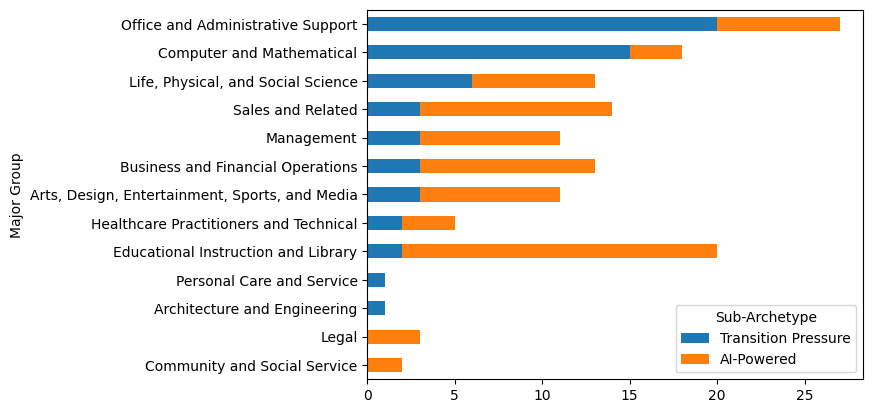

In [30]:
sub_archetype_df = pd.crosstab(active_transformation_df['Major Group'], active_transformation_df['Sub-Archetype'])
sub_archetype_df = sub_archetype_df.reindex(
    columns=['Transition Pressure', 'AI-Powered'],
    fill_value=0,
)
# sort values by largest to smallest
# sub_archetype_df = sub_archetype_df.loc[
#     sub_archetype_df.sum(axis=1).sort_values(ascending=False).index
# ][::-1]
sub_archetype_df.sort_values(by='Transition Pressure', inplace=True)
sub_archetype_df.plot(kind='barh', stacked=True);

In [31]:
final_exposure_df

,O*NET-SOC Code,Title,Major Group,AIOE,Complementarity,C-AIOE,Observed Exposure,LLM Rating Beta,Human Rating Beta,Archetype C-AIOE,Augmentation Percent,Automation Percent,Directive Percent,Feedback Loop Percent,Learning Percent,Task Iteration Percent,Validation Percent,None Percent,Sub-Archetype
344,37-3011.00,Landscaping and Groundskeeping Workers,Building and Grounds Cleaning and Maintenance,5.008307,41.270833,4.837189,0.0000,0.024390,0.024390,Limited Current Transformation,34.38,65.63,62.50,3.13,28.13,6.25,0.00,0.00,Transition Pressure
435,45-2092.00,"Farmworkers and Laborers, Crop, Nursery, and G...","Farming, Fishing, and Forestry",5.090957,53.270833,4.306101,0.0203,0.142857,0.071429,Limited Current Transformation,45.79,54.21,35.39,18.12,32.41,9.38,3.41,1.28,Transition Pressure
339,35-9011.00,Dining Room and Cafeteria Attendants and Barte...,Food Preparation and Serving Related,5.210569,52.979167,4.422471,0.0000,0.000000,0.000000,Limited Current Transformation,24.61,75.39,62.26,10.23,6.18,17.06,0.43,3.84,Transition Pressure
446,47-2142.00,Paperhangers,Construction and Extraction,5.253395,56.041667,4.297934,0.0000,0.027027,0.000000,Limited Current Transformation,62.96,37.04,25.00,10.71,0.00,53.57,7.14,3.57,AI-Powered
499,51-7011.00,Cabinetmakers and Bench Carpenters,Production,5.433540,51.729167,4.679636,0.0000,0.117647,0.044118,Limited Current Transformation,52.22,47.78,32.50,14.69,12.81,36.56,2.19,1.25,AI-Powered
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
448,47-2231.00,Solar Photovoltaic Installers,Construction and Extraction,5.591587,77.645833,3.366601,0.0000,0.110000,0.110000,Limited Current Transformation,2.45,97.55,92.10,4.56,1.22,0.91,0.30,0.91,Transition Pressure
437,47-1011.00,First-Line Supervisors of Construction Trades ...,Construction and Extraction,5.885910,80.020833,3.404018,0.0296,0.400000,0.200000,Limited Current Transformation,25.78,74.22,52.27,21.24,3.34,21.00,1.19,0.95,Transition Pressure
519,53-2031.00,Flight Attendants,Transportation and Material Moving,5.756917,79.166667,3.378591,0.0913,0.166667,0.145833,Limited Current Transformation,31.78,68.22,54.35,9.42,13.04,12.32,4.35,6.52,Transition Pressure
303,29-9091.00,Athletic Trainers,Healthcare Practitioners and Technical,5.873208,80.041667,3.395449,0.0531,0.279070,0.406977,Latent Transformation,55.58,44.42,20.87,23.35,10.73,42.93,1.66,0.46,AI-Powered


In [32]:
final_exposure_df.to_csv('../data/auxiliary/stage_3_archetypes.csv', index=False)

# Next steps

1. **Rerun Steps 2 and 3** with the fixed code, and update the counts and test results in the text.
2. **Decide the theoretical measure** (C-AIOE, AIOE or Human Beta), using the Question 1 comparison in Step 2b.
3. **Decide the usage threshold**, using the Question 2 sensitivity check in Step 2c.
4. **Build the Exposure-Usage Gap** (standardized difference between theoretical exposure and observed usage) from the concept note.
5. **Narrative report and crosswalk for MCA.** Explain why I introduced the Human and LLM Beta measures alongside C-AIOE, why the Eloundou et al. beta is the closer benchmark, and the risk that the two measures are correlated. Give a clearer reason for choosing the human-rated beta over the LLM-rated beta.
6. **Plain-language communication.** Share the results with non-technical audiences, for example through an infographic.